In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

We saved only one of the ten files present in the turbulent_radiative_layer_2D database, i.e. the one with *tcool = 0.10*.

For more informations, see [site with description](https://polymathic-ai.org/the_well/datasets/turbulent_radiative_layer_2D/)

The following code is taken from [the repo](https://github.com/PolymathicAI/the_well/blob/master/datasets/turbulent_radiative_layer_2D/visualization_turbulent_radiative_layer_2D.ipynb)

In [40]:
path = 'turbulent_radiative_layer_tcool_0.10.hdf5'

# print the first layer of keys
with h5py.File(path, "r") as f:
    print(f["t0_fields"]["density"].shape)
    print(f.keys())
    print(f["dimensions"]['time'][:])
    print(f["dimensions"]['x'][-1])
    print(f["dimensions"]['y'][1]-f["dimensions"]['y'][0])
    print(f["dimensions"]['y'][202]-f["dimensions"]['y'][201])
    

(8, 101, 128, 384)
<KeysViewHDF5 ['boundary_conditions', 'dimensions', 'scalars', 't0_fields', 't1_fields', 't2_fields']>
[  0.         1.597033   3.194066   4.791099   6.388132   7.985165
   9.582198  11.179231  12.776264  14.373297  15.97033   17.567364
  19.164396  20.761429  22.358461  23.955496  25.552528  27.14956
  28.746593  30.343628  31.94066   33.537693  35.134727  36.73176
  38.328793  39.925823  41.522858  43.119892  44.716923  46.313957
  47.91099   49.508022  51.105057  52.702087  54.29912   55.896156
  57.493187  59.09022   60.687256  62.284286  63.88132   65.478355
  67.075386  68.67242   70.269455  71.866486  73.46352   75.060555
  76.657585  78.254616  79.85165   81.448685  83.045715  84.642746
  86.239784  87.836815  89.433846  91.03088   92.627914  94.224945
  95.82198   97.419014  99.016045 100.613075 102.21011  103.807144
 105.404175 107.00121  108.59824  110.195274 111.79231  113.38934
 114.986374 116.58341  118.18044  119.77747  121.37451  122.97154
 124.56857 

In [3]:
# Reminder: 't0_fields', 't1_fields', 't2_fields' are respectively scalar fields, vector fields and tensor fields
# print the different fields available in the dataset
with h5py.File(path, "r") as f:
    print("t0_fields:", f["t0_fields"].keys())
    print("t1_fields:", f["t1_fields"].keys())
    print("t2_fields:", f["t2_fields"].keys())

t0_fields: <KeysViewHDF5 ['density', 'pressure']>
t1_fields: <KeysViewHDF5 ['velocity']>
t2_fields: <KeysViewHDF5 []>


In [ ]:
# The data is of shape (n_trajectories, n_timesteps, x, y)
# Get the first t0_field and save it as a numpy array
with h5py.File(path, "r") as f:
    density = f["t0_fields"]["density"][:] # HDF5 datasets can be sliced like a numpy array
    print("shape of the selected t0_field: ", density.shape)
    # you can directly slice the selected field without reading the whole dataset by doing:
    # traj = 0 #select the trajectory
    # field = f['t0_fields']['concentration'][traj, :]

shape of the selected t0_field:  (8, 101, 128, 384, 2)


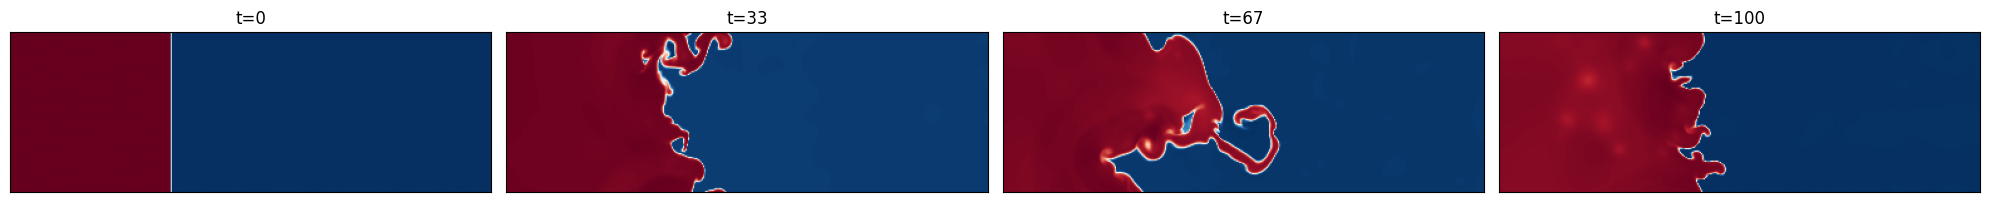

In [ ]:
traj = 4  # select the trajectory
traj_toplot = density[traj]
# THIS IS EXACTLY WHAT WE WANT TO USE

# field is now of shape (n_timesteps, x, y). Let's do a subplot to plot it at t= 0, t= T/3, t= 2T/3 and t= T:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
T = traj_toplot.shape[0]

# fix colorbar for all subplots:
normalize_plots = False
cmap = "RdBu_r"

if normalize_plots:
    vmin = np.min(traj_toplot)
    vmax = np.max(traj_toplot)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for i, t in enumerate([0, T // 3, (2 * T) // 3, T - 1]):
        axs[i].imshow(traj_toplot[t], cmap=cmap, norm=norm)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_title(f"t={t}")
else:
    for i, t in enumerate([0, T // 3, (2 * T) // 3, T - 1]):
        axs[i].imshow(np.log(traj_toplot[t]), cmap=cmap)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_title(f"t={t}")
plt.tight_layout()

In [60]:
# Extract datasets for density, pressure and velocity
traj = 4  # select the trajectory
with h5py.File(path, "r") as f:
    time_points = f["dimensions"]['time'][:]
    x_points = f["dimensions"]['x'][:]
    y_points = f["dimensions"]['y'][:]
    density = f["t0_fields"]["density"][traj]  # shape (n_timesteps, x, y)
    pressure = f["t0_fields"]["pressure"][traj]  # shape (n_timesteps, x, y)
    velocity = f["t1_fields"]["velocity"][traj]  # shape (n_timesteps, x, y, 2)

labels = np.concatenate([density[..., np.newaxis], pressure[..., np.newaxis], velocity], axis=-1)

print("shape of the final dataset: ", labels.shape)  # should be (n_timesteps, x, y, 4)

shape of the final dataset:  (101, 128, 384, 4)


In [ ]:
# Reshape labels to (n_timesteps*x*y, 4)
labels_reshaped = labels.reshape(-1, 4)
print("shape of the reshaped dataset: ", labels_reshaped.shape)

# Chek the order in which np.reshape works: it moves the last label first (in our case, fixes t,x and moves y first)
assert all(labels_reshaped[1,:] == labels[0,0,1,:]) # firstly moves y
assert all(labels_reshaped[labels.shape[2],:] == labels[0,1,0,:]) # then moves x
assert all(labels_reshaped[labels.shape[1]*labels.shape[2],:] == labels[1,0,0,:]) # lastly t

shape of the reshaped dataset:  (4964352, 4)


In [ ]:
# Create meshgrid for t,x,y
T, X, Y = np.meshgrid(time_points, x_points, y_points, indexing='ij')

# Flatten the coordinates and field
T_flat = T.ravel()
X_flat = X.ravel()
Y_flat = Y.ravel()

In [ ]:
# Create final dataset
dataset_array = np.concatenate([T_flat[..., np.newaxis], X_flat[..., np.newaxis], Y_flat[..., np.newaxis], labels_reshaped], axis=-1)